In [15]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np

# 1. Carga de datos

In [4]:
# Carga de datos
print("[INFO]: Loading CIFAR-100 data...")
((x_train, y_train), (x_test, y_test)) = cifar100.load_data()

# CIFAR100 labelnames
labelNames = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']


[INFO]: Loading CIFAR-100 data...


In [5]:
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Number of classes: {len(labelNames)}")

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Number of classes: 100


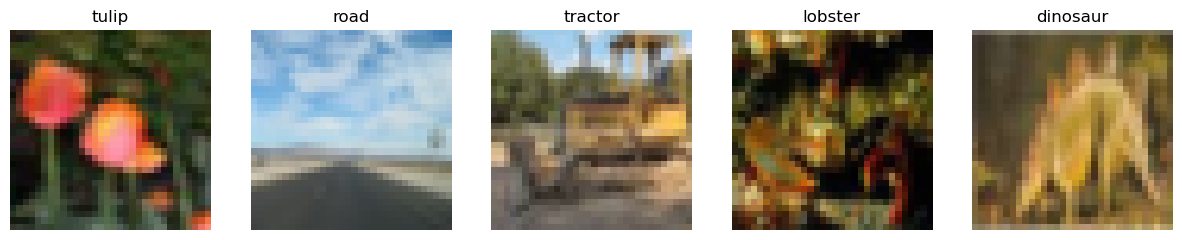

In [6]:
# Seleccionamos 5 índices aleatorios para mostrar las imágenes
num_images = 5
random_indices = np.random.choice(x_train.shape[0], num_images, replace=False)

# Visualizamos las imágenes seleccionadas aleatoriamente
fig, axes = plt.subplots(1, num_images, figsize=(15, 15))

for i, idx in enumerate(random_indices):
    ax = axes[i]
    ax.imshow(x_train[idx])  # Muestra la imagen
    ax.set_title(labelNames[y_train[idx][0]])  # Muestra la etiqueta
    ax.axis('off')  # Desactiva los ejes para mejor presentación

plt.show()

Comprobamos el formato de las etiquetas de entrenamiento

In [7]:
print(y_train[:5])  # Imprime las primeras 5 etiquetas de entrenamiento

[[19]
 [29]
 [ 0]
 [11]
 [ 1]]


# 2. Preprocesamiento de imagenes

In [8]:
x_train_resized = tf.image.resize(x_train, (224, 224))
x_test_resized = tf.image.resize(x_test, (224, 224))

In [9]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 3. Definición del modelo preentrenado

In [10]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

In [11]:
base_model.trainable = False

In [12]:
model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(100, activation='softmax'))

In [16]:
model = load_model("modelo_v1.keras")

In [17]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy',  # Función de pérdida correcta para etiquetas enteras
              metrics=['accuracy'])

In [18]:
print(model.summary())  # Verifica la arquitectura del modelo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,792,612 (90.76 MB)

 Trainable params: 204,900 (800.39 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [19]:
# Descongelar las últimas capas de ResNet50
model.layers[0].trainable = True  # Permite entrenar ResNet50

# Opcional: descongelar solo las últimas 10 capas de ResNet50
for layer in model.layers[0].layers[:-10]:  
    layer.trainable = False

# Compilar de nuevo después de modificar las capas entrenables
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [20]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Normalizar los datos correctamente
x_train = preprocess_input(x_train.astype("float32"))
x_test = preprocess_input(x_test.astype("float32"))

# 4. Entrenar el modelo

In [21]:
model.compile(optimizer=Adam(learning_rate=1e-4),  # Reducir la tasa de aprendizaje
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [22]:
# Entrenamos el modelo
history = model.fit(x_train_resized, y_train,  # Conjunto de entrenamiento
                    validation_data=(x_test_resized, y_test),  # Validación en el conjunto de prueba
                    epochs=20,  # Número de épocas (ajusta según sea necesario)
                    batch_size=32)  # Tamaño del batch

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 722s 460ms/step - accuracy: 0.8298 - loss: 0.5616 - val_accuracy: 0.6778 - val_loss: 1.1793
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 720s 460ms/step - accuracy: 0.9451 - loss: 0.2447 - val_accuracy: 0.6771 - val_loss: 1.2632
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 705s 451ms/step - accuracy: 0.9849 - loss: 0.1111 - val_accuracy: 0.6820 - val_loss: 1.3148
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 705s 451ms/step - accuracy: 0.9943 - loss: 0.0607 - val_accuracy: 0.6829 - val_loss: 1.3226
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 704s 450ms/step - accuracy: 0.9963 - loss: 0.0423 - val_accuracy: 0.6729 - val_loss: 1.4433
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 704s 450ms/step - accuracy: 0.9959 - loss: 0.0385 - val_accuracy: 0.6813 - val_loss: 1.4417
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 703s 449ms/step - accuracy: 0.9968 - loss: 0.0297 - val_accuracy: 0.6638 - val_loss: 1.5128
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 706s 451ms/step - ac

In [16]:
model.save("modelo_v1.keras")  # Guarda el modelo en un archivo

# 5. Probar el modelo

In [23]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4%}")  # Convierte a porcentaje

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.0109 - loss: 16.7035
Test Loss: 16.7556
Test Accuracy: 1.0100%
